# Level 1 · Task 1 — Data Preprocessing for Machine Learning

**Goal:** take the raw `sentiment.csv` dataset and make it fully ready for machine learning.

**What we'll do (as per the task requirements):**
1. Explore the raw data and find quality issues
2. Handle missing data (median fill / dropping)
3. Encode categorical variables (one-hot + label encoding)
4. Normalize/standardize numerical features
5. Split into training and testing sets

*Tools: Python, pandas, scikit-learn*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.width', 120)
pd.set_option('display.max_columns', 30)

df = pd.read_csv('../data/sentiment.csv')
print('shape:', df.shape)
df.head()

shape: (732, 15)


,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [2]:
# quick overview of columns and types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  732 non-null    int64  
 1   Unnamed: 0    732 non-null    int64  
 2   Text          732 non-null    object 
 3   Sentiment     732 non-null    object 
 4   Timestamp     732 non-null    object 
 5   User          732 non-null    object 
 6   Platform      732 non-null    object 
 7   Hashtags      732 non-null    object 
 8   Retweets      732 non-null    float64
 9   Likes         732 non-null    float64
 10  Country       732 non-null    object 
 11  Year          732 non-null    int64  
 12  Month         732 non-null    int64  
 13  Day           732 non-null    int64  
 14  Hour          732 non-null    int64  
dtypes: float64(2), int64(6), object(7)
memory usage: 85.9+ KB


In [3]:
# missing values and duplicates
print('Missing values per column:')
print(df.isna().sum())
print('\nDuplicate rows:', df.duplicated().sum())

Missing values per column:
Unnamed: 0.1    0
Unnamed: 0      0
Text            0
Sentiment       0
Timestamp       0
User            0
Platform        0
Hashtags        0
Retweets        0
Likes           0
Country         0
Year            0
Month           0
Day             0
Hour            0
dtype: int64

Duplicate rows: 0


In [4]:
# the target column looks messy — let's check
print('unique sentiment labels:', df['Sentiment'].nunique())
print('\na few raw examples:')
print(df['Sentiment'].sample(12, random_state=1).tolist())

unique sentiment labels: 279

a few raw examples:
[' Inspiration  ', ' Excitement ', ' Enthusiasm    ', ' Resilience ', ' Bad ', ' Ambivalence     ', ' Joy ', ' Zest ', ' Anticipation  ', ' Desolation ', ' Fulfillment  ', ' Bitter       ']


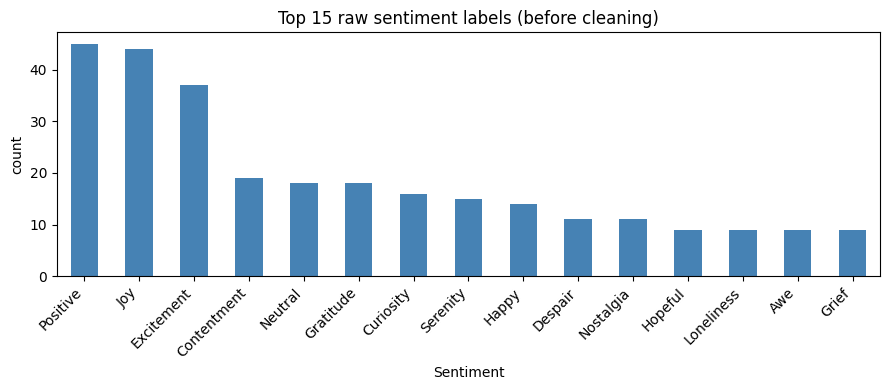

In [5]:
# top 15 most frequent raw labels
top = df['Sentiment'].str.strip().value_counts().head(15)

plt.figure(figsize=(9, 4))
top.plot(kind='bar', color='steelblue')
plt.title('Top 15 raw sentiment labels (before cleaning)')
plt.ylabel('count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Step 1 — Cleaning the data

Issues found in the exploration:
- extra **whitespace** inside string values (`' Twitter  '`, `' Positive  '`)
- two useless **index columns** (`Unnamed: 0` and the first unnamed one)
- **missing values** in some numeric columns
- **~180 different sentiment labels**, some being stray phrases — needs consolidation

In [6]:
# strip whitespace from all string columns
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

# drop redundant index columns
df = df.drop(columns=['Unnamed: 0'])
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# drop exact duplicate rows
before = len(df)
df = df.drop_duplicates()
print(f'dropped {before - len(df)} duplicate rows -> {len(df)} rows left')

dropped 22 duplicate rows -> 710 rows left


In [7]:
# handle missing values
# - numeric columns -> fill with median (robust to outliers)
# - rows missing the target label -> drop
num_cols = ['Retweets', 'Likes']
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

df = df.dropna(subset=['Sentiment'])
df['Text'] = df['Text'].fillna('')
df['Hashtags'] = df['Hashtags'].fillna('')

print('missing values after cleaning:')
print(df.isna().sum().sum(), 'total')

missing values after cleaning:
0 total


In [8]:
# consolidate the messy ~180 labels into 3 clean classes
POSITIVE = ['positive', 'joy', 'happy', 'excit', 'content', 'gratit', 'love', 'proud',
            'pride', 'awe', 'euphor', 'enthus', 'seren', 'calm', 'hope', 'inspir',
            'determin', 'amuse', 'tender', 'affect', 'ador', 'kind', 'compassion',
            'delight', 'bliss', 'festive', 'celebr', 'charm', 'ecstas', 'triumph',
            'success', 'wonder', 'amaz', 'thrill', 'zest', 'relief', 'rejuv',
            'resilien', 'tranquil', 'solace', 'playful', 'energ', 'spark', 'dazzle',
            'enchant', 'fulfill', 'touched', 'heartwarm', 'empower', 'satisf',
            'optimis', 'motivat', 'bless', 'freedom', 'friend', 'roman', 'creativ',
            'confiden', 'magic', 'breakthrough', 'elat', 'grateful']

NEGATIVE = ['negative', 'despair', 'loneli', 'grief', 'sad', 'sorrow', 'anger', 'hate',
            'frustrat', 'fear', 'anxie', 'melanchol', 'embarrass', 'regret', 'shame',
            'betray', 'bitter', 'disgust', 'devast', 'jealous', 'resent', 'envy',
            'heartbreak', 'desp', 'dark', 'ruin', 'loss', 'lost', 'exhaust', 'suffer',
            'pressur', 'intimid', 'helpless', 'miser', 'pain', 'rage', 'storm',
            'overwhelm', 'isolat', 'broken', 'bad']

def simplify_sentiment(label):
    l = str(label).lower()
    if any(k in l for k in NEGATIVE):
        return 'Negative'
    if any(k in l for k in POSITIVE):
        return 'Positive'
    return 'Neutral'

df['Sentiment'] = df['Sentiment'].apply(simplify_sentiment)
df['Sentiment'].value_counts()

Sentiment
Positive    360
Neutral     194
Negative    156
Name: count, dtype: int64

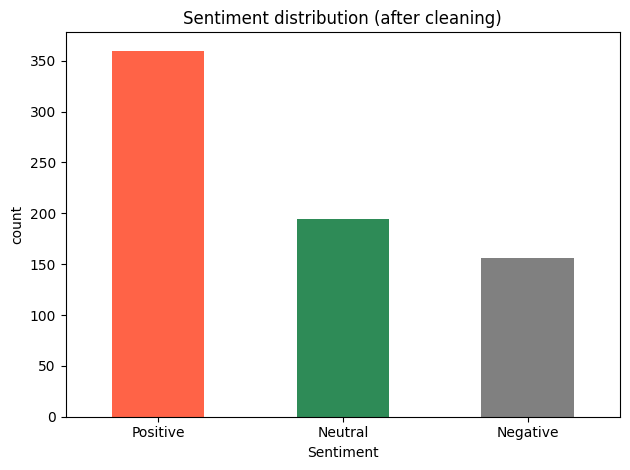

In [9]:
# labelled distribution after cleaning
df['Sentiment'].value_counts().plot(kind='bar', color=['tomato', 'seagreen', 'gray'])
plt.title('Sentiment distribution (after cleaning)')
plt.ylabel('count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Step 2 — Feature engineering & encoding categorical variables

- derive simple numeric features from the raw text fields
- **one-hot encode** `Platform` and `Country`
- **label encode** the target `Sentiment`

In [10]:
# simple numeric features from text
df['text_length'] = df['Text'].str.len()
df['hashtag_count'] = df['Hashtags'].str.count('#').fillna(0).astype(int)

# drop columns we no longer need (raw text / identifiers)
df = df.drop(columns=['Text', 'User', 'Timestamp', 'Hashtags'])

# drop constant columns (a column with a single value carries no information)
constant_cols = [c for c in df.columns if df[c].nunique() == 1]
if constant_cols:
    print('dropping constant columns:', constant_cols)
    df = df.drop(columns=constant_cols)

df.head()

dropping constant columns: ['hashtag_count']


,Sentiment,Platform,Retweets,Likes,Country,Year,Month,Day,Hour,text_length
0,Positive,Twitter,15.0,30.0,USA,2023,1,15,12,37
1,Negative,Twitter,5.0,10.0,Canada,2023,1,15,8,34
2,Positive,Instagram,20.0,40.0,USA,2023,1,15,15,35
3,Positive,Facebook,8.0,15.0,UK,2023,1,15,18,43
4,Neutral,Instagram,12.0,25.0,Australia,2023,1,15,19,43


In [11]:
# one-hot encode categorical features
cat_cols = ['Platform', 'Country']
df = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=int)

# label encode the target
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Sentiment'] = le.fit_transform(df['Sentiment'])

print('class mapping:', dict(zip(le.classes_, le.transform(le.classes_))))
print('\nshape after encoding:', df.shape)
df.head()

class mapping: {'Negative': np.int64(0), 'Neutral': np.int64(1), 'Positive': np.int64(2)}

shape after encoding: (710, 42)


,Sentiment,Retweets,Likes,Year,Month,Day,Hour,text_length,Platform_Instagram,Platform_Twitter,Country_Austria,Country_Belgium,Country_Brazil,Country_Cambodia,Country_Canada,...,Country_Jordan,Country_Kenya,Country_Maldives,Country_Netherlands,Country_Norway,Country_Peru,Country_Portugal,Country_Scotland,Country_South Africa,Country_Spain,Country_Sweden,Country_Switzerland,Country_Thailand,Country_UK,Country_USA
0,2,15.0,30.0,2023,1,15,12,37,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
1,0,5.0,10.0,2023,1,15,8,34,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,2,20.0,40.0,2023,1,15,15,35,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
3,2,8.0,15.0,2023,1,15,18,43,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
4,1,12.0,25.0,2023,1,15,19,43,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## Step 3 — Normalize / standardize numerical features

Scaling the continuous features to zero mean and unit variance so that
features on big scales (likes, retweets) don't dominate the model.

In [12]:
from sklearn.preprocessing import StandardScaler

# note: hashtag_count turned out constant in this dataset, so it was
# dropped earlier — scale only the numeric columns that remain
scale_cols = [c for c in ['Retweets', 'Likes', 'text_length', 'hashtag_count']
              if c in df.columns]
print('scaling columns:', scale_cols)

print('BEFORE scaling:')
print(df[scale_cols].describe().loc[['mean', 'std']].round(2))

scaler = StandardScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])

print('\nAFTER scaling:')
print(df[scale_cols].describe().loc[['mean', 'std']].round(2))

scaling columns: ['Retweets', 'Likes', 'text_length']
BEFORE scaling:
      Retweets  Likes  text_length
mean     21.55  42.98        83.69
std       7.12  14.20        31.22

AFTER scaling:
      Retweets  Likes  text_length
mean      -0.0    0.0         -0.0
std        1.0    1.0          1.0


## Step 4 — Train / test split

80% train, 20% test, stratified on the target so the class balance
is preserved in both sets.

In [13]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Sentiment'])
y = df['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('X_train:', X_train.shape, ' X_test:', X_test.shape)
print('y_train:', y_train.shape, '   y_test:', y_test.shape)

print('\nclass balance (train):')
print((y_train.value_counts(normalize=True) * 100).round(1).astype(str) + '%')

X_train: (568, 41)  X_test: (142, 41)
y_train: (568,)    y_test: (142,)

class balance (train):
Sentiment
2    50.7%
1    27.3%
0    22.0%
Name: proportion, dtype: object


## Summary ✔

| Requirement | Done |
|---|---|
| Handle missing data | ✔ median fill + dropped unlabeled rows |
| Encode categorical variables | ✔ one-hot (Platform, Country) + label encoding (target) |
| Normalize/standardize numeric features | ✔ StandardScaler |
| Train-test split | ✔ 80/20 stratified |

The dataset is now clean, fully numeric and ready to feed into any ML model.